# Tutorial 4: Fitting with MAP Optimization

This tutorial demonstrates fitting mock galaxies using diffsed's gradient-based MAP optimization. We show:
1. **Photometry-only** fitting (5 SDSS bands)
2. **Parameter fixing** — fix some parameters, fit others
3. **SNR dependence** — how noise level affects recovery
4. **Batch mock generation** — sample from priors, generate many galaxies
5. **Fitter API** — direct control for chaining MAP to NUTS/Ray Tracing
6. **Derived quantities** — stellar mass, SFR, sSFR from fitted SFH
7. **Spectroscopic fitting** — fitting a full spectrum instead of broadband photometry

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "../src")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time

from diffsed import (
    Model, ParamSpec, Fitter, Uniform, Gaussian, Fixed,
    load_ssp_data, load_filter_set,
)

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
})

ssp = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
filter_names = ["u", "g", "r", "i", "z"]

---
## 1. Photometric Fitting

Define a parametric model (no stochastic SFH) and fit a mock galaxy with MAP. The `ParamSpec` sets which parameters are free (`Uniform(lo, hi)`) and which are fixed (scalar values).

In [2]:
spec = ParamSpec(
    sfh_alpha        = Uniform(0.5, 3.0),
    sfh_beta         = Uniform(0.3, 2.0),
    sfh_tau_peak_gyr = Uniform(0.5, 10.0),
    sfh_peak_sfr     = Uniform(0.1, 50.0),
    met_logzsol      = -0.2,            # fixed (poorly constrained by 5 bands)
    dust_tau_bc      = Uniform(0.0, 3.0),
    dust_tau_diff    = 0.3,              # fixed
    dust_slope       = -0.7,
    redshift         = 0.1,
    stochastic       = False,
)

model = Model(spec, ssp, filters=filters)

true_params = {
    "sfh_alpha": 1.0, "sfh_beta": 0.8,
    "sfh_tau_peak_gyr": 3.0, "sfh_peak_sfr": 10.0,
    "met_logzsol": -0.2,
    "dust_tau_bc": 0.8, "dust_tau_diff": 0.3,
    "dust_slope": -0.7, "redshift": 0.1,
}

mock = model.mock(true_params, snr=20.0, key=jax.random.PRNGKey(0))

result = model.fit(
    mock.flux_obs, mock.noise,
    method="map", n_steps=5000, learning_rate=0.05, verbose=True, print_every=500,
)

print(f"\nFinal loss: {result.diagnostics['final_loss']:.4f}")
print(f"Wall time: {result.wall_time_s:.1f}s")

W0314 10:23:07.749565 3425420 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  Step     0/5000: loss = 716.8275
  Step   500/5000: loss = 1.6512
  Step  1000/5000: loss = 1.6406
  Step  1500/5000: loss = 1.6306
  Step  2000/5000: loss = 1.6204
  Step  2500/5000: loss = 1.6077
  Step  3000/5000: loss = 1.5917


  Step  3500/5000: loss = 1.5737
  Step  4000/5000: loss = 1.5579
  Step  4500/5000: loss = 1.5487
  Step  4999/5000: loss = 1.5456
  MAP (ADAM) complete in 0.5s, 5000 steps

Final loss: 1.5456
Wall time: 0.5s


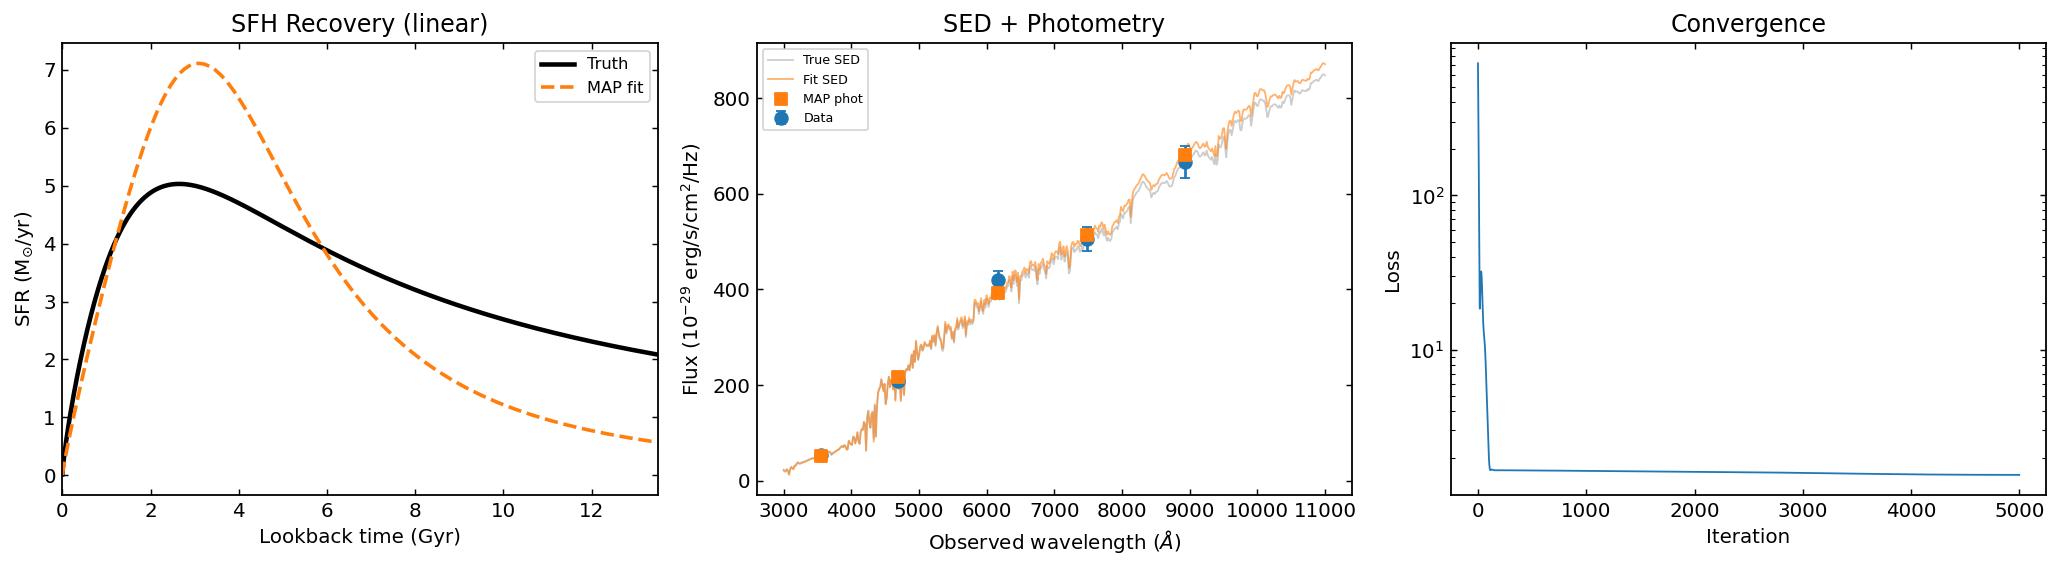

Parameter                  True      Fit
----------------------------------------
dust_slope                 -0.7     -0.7
dust_tau_bc                 0.8  0.00824
dust_tau_diff               0.3      0.3
met_logzsol                -0.2     -0.2
redshift                    0.1      0.1
sfh_alpha                     1     2.63
sfh_beta                    0.8    0.904
sfh_peak_sfr                 10     12.6
sfh_tau_peak_gyr              3     4.19


In [3]:
# Results
sfh_true = model.predict_sfh(true_params)
sfh_fit = model.predict_sfh(result.params)
phot_fit = model.predict_photometry(result.params)

# SED for background
wave_obs = jnp.linspace(3000, 11000, 500)
sed_true = model.predict_spectrum(true_params, wave_obs)
sed_fit = model.predict_spectrum(result.params, wave_obs)
wave_eff = jnp.array([3551, 4686, 6166, 7480, 8932])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# SFH (linear)
ax = axes[0]
ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2.5, label="Truth")
ax.plot(sfh_fit["t_gyr"], sfh_fit["sfr_mean"], "C1--", lw=2, label="MAP fit")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("SFH Recovery (linear)")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=9)

# SED + photometry
ax = axes[1]
ax.plot(wave_obs, sed_true * 1e29, color="gray", alpha=0.4, lw=1, label="True SED")
ax.plot(wave_obs, sed_fit * 1e29, color="C1", alpha=0.6, lw=1, label="Fit SED")
ax.errorbar(wave_eff, mock.flux_obs * 1e29, yerr=mock.noise * 1e29,
             fmt="o", color="C0", ms=7, capsize=3, label="Data")
ax.scatter(wave_eff, phot_fit * 1e29, color="C1", marker="s", s=50, zorder=10, label="MAP phot")
ax.set_xlabel(r"Observed wavelength ($\AA$)")
ax.set_ylabel(r"Flux ($10^{-29}$ erg/s/cm$^2$/Hz)")
ax.set_title("SED + Photometry")
ax.legend(fontsize=7)

# Loss
ax = axes[2]
ax.plot(result.loss_history, "C0", lw=1)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_title("Convergence")

plt.tight_layout()
plt.show()

# Parameter table
summary = result.summary()
print(f"{'Parameter':<22s} {'True':>8s} {'Fit':>8s}")
print("-" * 40)
for name in sorted(true_params.keys()):
    if name in summary:
        print(f"{name:<22s} {true_params[name]:>8.3g} {summary[name]['value']:>8.3g}")

---
## 2. Parameter Fixing

Fix dust and metallicity to their known values. With fewer free parameters, the SFH recovery improves because there's less age-dust-metallicity degeneracy.

Free: 4 params (was 5)


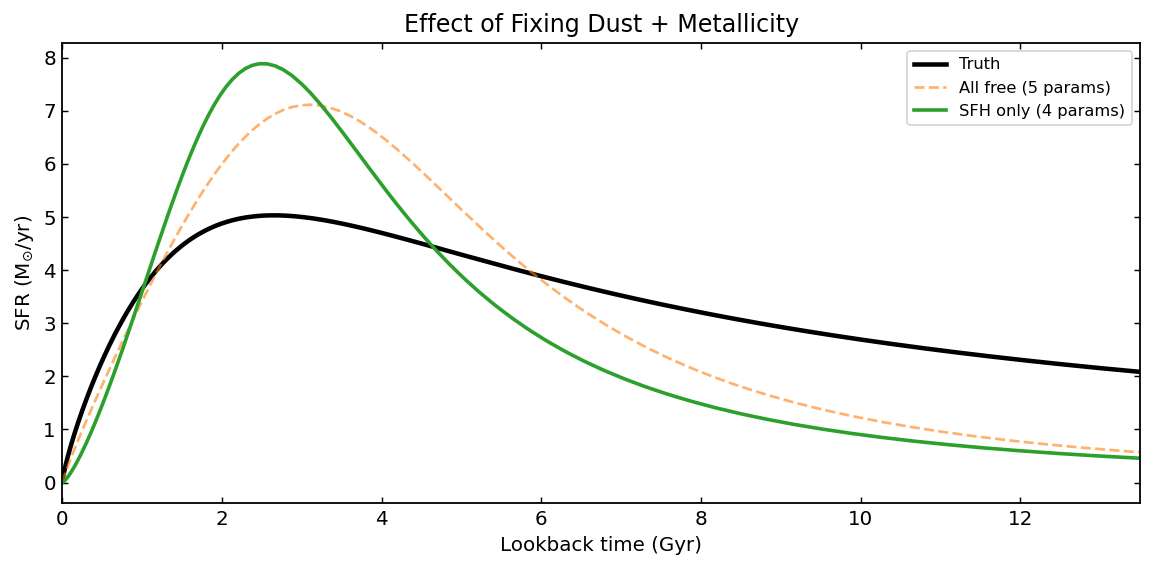

In [4]:
spec_fixed = ParamSpec(
    sfh_alpha        = Uniform(0.5, 3.0),
    sfh_beta         = Uniform(0.3, 2.0),
    sfh_tau_peak_gyr = Uniform(0.5, 10.0),
    sfh_peak_sfr     = Uniform(0.1, 50.0),
    met_logzsol      = -0.3,       # FIXED
    dust_tau_bc      = 1.0,        # FIXED
    dust_tau_diff    = 0.3,        # FIXED
    dust_slope       = -0.7,
    redshift         = 0.1,
    stochastic       = False,
)
model_fixed = Model(spec_fixed, ssp, filters=filters)

print(f"Free: {spec_fixed.n_free} params (was {spec.n_free})")

result_fixed = model_fixed.fit(
    mock.flux_obs, mock.noise,
    method="map", n_steps=1500, verbose=False,
)

sfh_fixed = model_fixed.predict_sfh(result_fixed.params)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2.5, label="Truth")
ax.plot(sfh_fit["t_gyr"], sfh_fit["sfr_mean"], "C1--", lw=1.5,
        label=f"All free ({spec.n_free} params)", alpha=0.6)
ax.plot(sfh_fixed["t_gyr"], sfh_fixed["sfr_mean"], "C2-", lw=2,
        label=f"SFH only ({spec_fixed.n_free} params)")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("Effect of Fixing Dust + Metallicity")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. SNR Dependence

SNR= 5: loss=2.4, time=0.3s


SNR=10: loss=1.3, time=0.2s


SNR=20: loss=0.9, time=0.2s


SNR=50: loss=7.9, time=0.3s


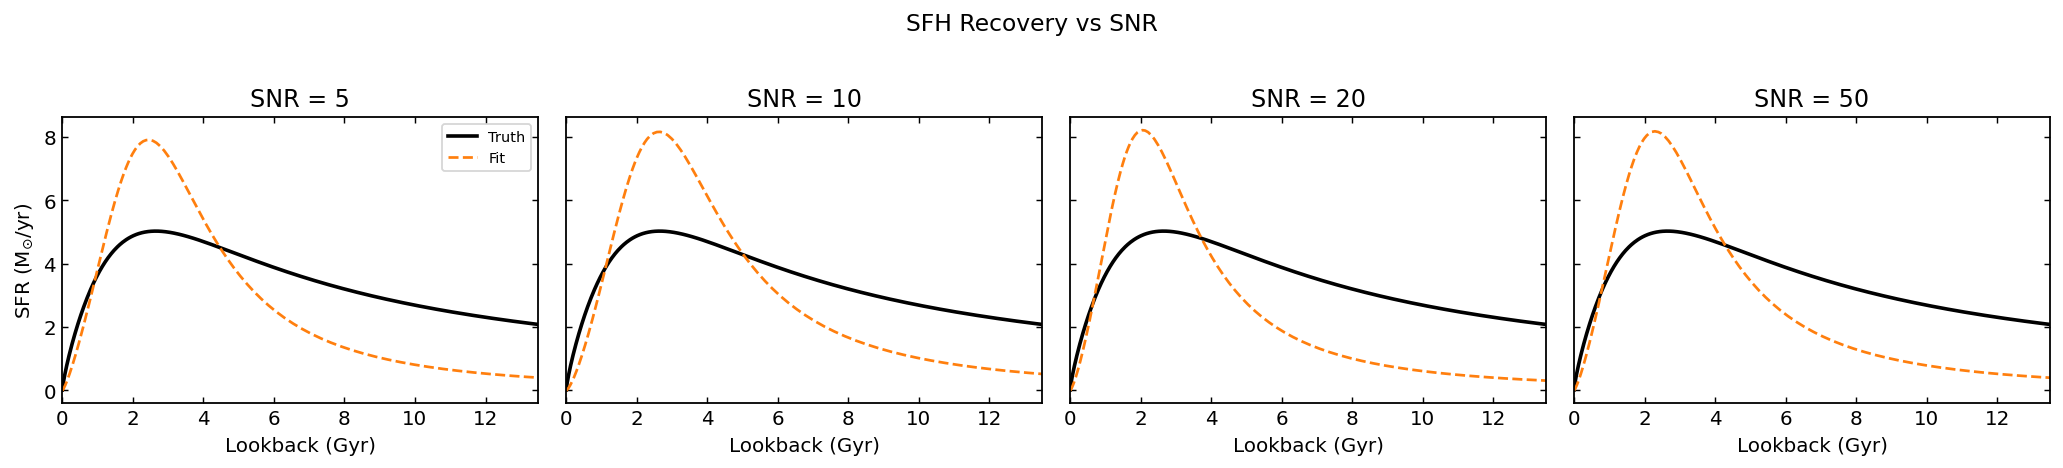

In [5]:
snr_values = [5, 10, 20, 50]
results_snr = {}

for snr in snr_values:
    m = model.mock(true_params, snr=snr, key=jax.random.PRNGKey(int(snr)))
    r = model.fit(m.flux_obs, m.noise, method="map", n_steps=1500, verbose=False)
    results_snr[snr] = r
    print(f"SNR={snr:2d}: loss={r.diagnostics['final_loss']:.1f}, time={r.wall_time_s:.1f}s")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, snr in zip(axes, snr_values):
    sfh_s = model.predict_sfh(results_snr[snr].params)
    ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2, label="Truth")
    ax.plot(sfh_s["t_gyr"], sfh_s["sfr_mean"], "C1--", lw=1.5, label="Fit")
    ax.set_xlabel("Lookback (Gyr)")
    ax.set_title(f"SNR = {snr}")
    ax.set_xlim(0, 13.5)
    if ax == axes[0]:
        ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
        ax.legend(fontsize=8)
plt.suptitle("SFH Recovery vs SNR", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Batch Mock Generation

In [6]:
# Sample 10 galaxies from the prior
param_batch = spec.sample_batch(jax.random.PRNGKey(42), n=10)
mock_batch = model.mock_batch(param_batch, snr=20.0, key=jax.random.PRNGKey(43))

print(f"Generated {mock_batch.flux_true.shape[0]} galaxies, "
      f"{mock_batch.flux_true.shape[1]} bands each")

# Fit each
batch_results = []
t0 = time.time()
for i in range(10):
    r = model.fit(mock_batch.flux_obs[i], mock_batch.noise[i],
                  method="map", n_steps=1500, verbose=False)
    batch_results.append(r)
total = time.time() - t0
print(f"Fit 10 galaxies in {total:.1f}s ({total/10:.1f}s each)")

Generated 10 galaxies, 5 bands each


Fit 10 galaxies in 2.3s (0.2s each)


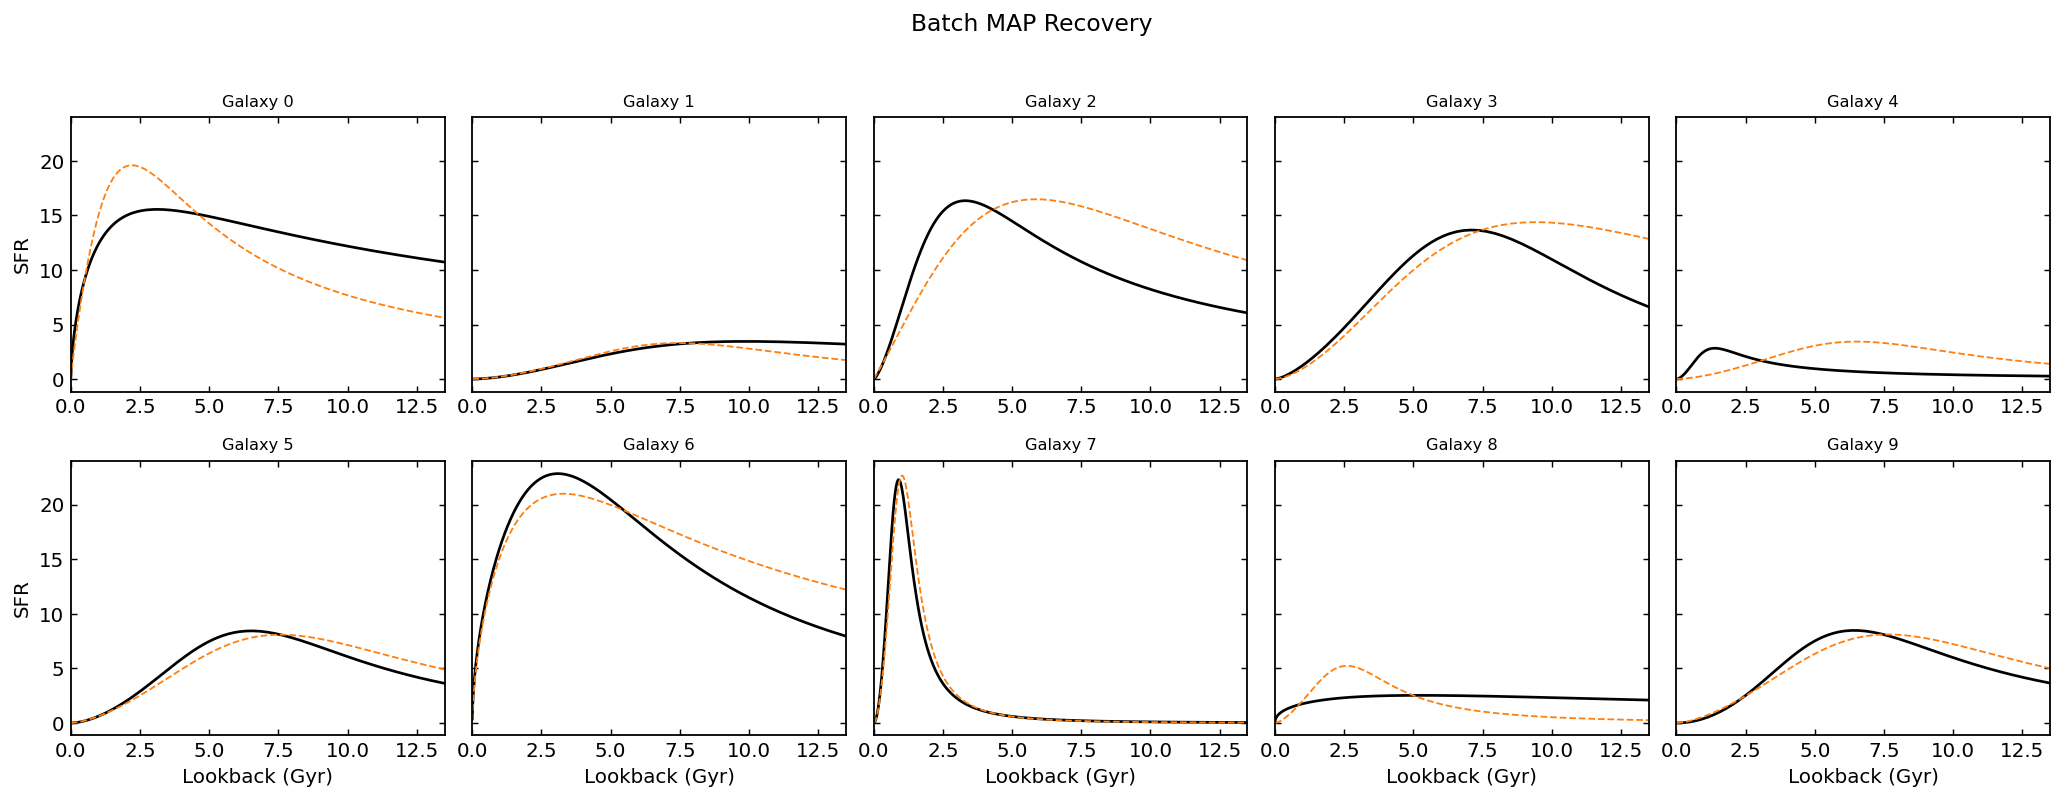

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)
for idx, (ax, res) in enumerate(zip(axes.ravel(), batch_results)):
    true_i = {k: v[idx] for k, v in param_batch.items()}
    sfh_t = model.predict_sfh(true_i)
    sfh_f = model.predict_sfh(res.params)
    ax.plot(sfh_t["t_gyr"], sfh_t["sfr_mean"], "k-", lw=1.5)
    ax.plot(sfh_f["t_gyr"], sfh_f["sfr_mean"], "C1--", lw=1)
    ax.set_xlim(0, 13.5)
    ax.set_title(f"Galaxy {idx}", fontsize=9)
    if idx % 5 == 0: ax.set_ylabel("SFR")
    if idx >= 5: ax.set_xlabel("Lookback (Gyr)")
plt.suptitle("Batch MAP Recovery", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Using the Fitter Directly

For chaining methods (e.g., MAP initialization for NUTS), use `Fitter` explicitly.

In [8]:
fitter = Fitter(model, mock.flux_obs, mock.noise)

# MAP first
r_map = fitter.run("map", n_steps=1000, verbose=False)
print(f"MAP: loss={r_map.diagnostics['final_loss']:.2f}, time={r_map.wall_time_s:.1f}s")

# Chain to NUTS
try:
    r_nuts = fitter.run("nuts", init_from=r_map, n_warmup=100, n_samples=50, verbose=True)
    print(f"NUTS: divergences={r_nuts.diagnostics['n_divergent']}, time={r_nuts.wall_time_s:.1f}s")
except ImportError:
    print("BlackJAX not installed")

MAP: loss=1.64, time=0.2s


NUTS: 5 parameters, 100 warmup, 50 samples, target_accept=0.8


  Warmup complete (1.4s). Step size: 0.0478


  Sample 50/50
  NUTS complete in 3.2s. Divergences: 2/50
NUTS: divergences=2, time=3.2s


### Ray Tracing Sampler (Behroozi 2025)

The ray tracing sampler is a gradient-based MCMC method that uses leapfrog integration
(like NUTS) but with a simpler trajectory strategy and optional momentum refreshment.
It is faster than NUTS per effective sample and avoids the U-turn criterion overhead,
making it well-suited for moderate-dimensional SED fitting problems.

In [9]:
# Ray Tracing: initialize from the MAP result above
r_rts = fitter.run(
    "raytrace",
    init_from=r_map,
    n_steps=400,
    n_leapfrog_steps=10,
    n_burnin=100,
    verbose=True,
)

print(f"\nRay Tracing: {r_rts.diagnostics['n_samples']} samples, "
      f"accept={r_rts.diagnostics['accept_rate']:.2f}, "
      f"time={r_rts.wall_time_s:.1f}s")

# Parameter summary
summary_rts = r_rts.summary()
print(f"\n{'Parameter':<22s} {'True':>8s} {'Median':>8s} {'Std':>8s}")
print("-" * 50)
for name in sorted(true_params.keys()):
    if name in summary_rts:
        s = summary_rts[name]
        print(f"{name:<22s} {true_params[name]:>8.3g} {s['median']:>8.3g} {(s['hi_68'] - s['lo_68'])/2:>8.3g}")

Ray Tracing: 5 params, 100 burn-in + 400 samples, 10 leapfrog/step, step_size=0.0671


  Ray Tracing complete in 0.3s. Acceptance: 36.7% (overall), 33.4% (post burn-in). Samples: 400

Ray Tracing: 400 samples, accept=0.37, time=0.3s

Parameter                  True   Median      Std
--------------------------------------------------
dust_slope                 -0.7     -0.7        0
dust_tau_bc                 0.8   0.0033   0.0158
dust_tau_diff               0.3      0.3        0
met_logzsol                -0.2     -0.2        0
redshift                    0.1      0.1        0
sfh_alpha                     1     1.29    0.622
sfh_beta                    0.8     1.82    0.485
sfh_peak_sfr                 10     13.3     2.78
sfh_tau_peak_gyr              3     1.79     1.01


---
## 6. Derived Quantities

In [10]:
d_true = model.predict_derived(true_params)
d_fit = model.predict_derived(result.params)

print(f"{'Quantity':<20s} {'True':>12s} {'Fit':>12s} {'Units'}")
print("-" * 60)
print(f"{'stellar_mass':<20s} {float(d_true['stellar_mass']):>12.3e} {float(d_fit['stellar_mass']):>12.3e} {'Msun'}")
print(f"{'sfr_100myr':<20s} {float(d_true['sfr_100myr']):>12.3f} {float(d_fit['sfr_100myr']):>12.3f} {'Msun/yr'}")
print(f"{'ssfr':<20s} {float(d_true['ssfr']):>12.3e} {float(d_fit['ssfr']):>12.3e} {'yr^-1'}")

Quantity                     True          Fit Units
------------------------------------------------------------
stellar_mass            4.577e+10    4.230e+10 Msun
sfr_100myr                  0.175        0.102 Msun/yr
ssfr                    3.815e-12    2.408e-12 yr^-1


---
## 7. Spectroscopic Fitting

The `Fitter` also supports fitting full spectra instead of broadband photometry.
Pass `data_type="spectroscopy"` and set `model._wave_obs` to the observed wavelength grid.
This provides much stronger constraints on SFH shape, metallicity, and dust because
the spectrum carries per-pixel information rather than integrated band fluxes.

In [11]:
# Define a spectroscopic wavelength grid (rest-frame optical, R ~ 100)
wave_spec = jnp.linspace(3800, 9000, 200)

# Generate mock spectrum with noise
spec_true = model.predict_spectrum(true_params, wave_spec)
snr_spec = 30.0
noise_spec = spec_true / snr_spec
flux_spec_obs = spec_true + noise_spec * jax.random.normal(
    jax.random.PRNGKey(99), shape=spec_true.shape
)

print(f"Spectroscopic mock: {len(wave_spec)} pixels, "
      f"SNR={snr_spec:.0f}, range={float(wave_spec[0]):.0f}-{float(wave_spec[-1]):.0f} A")

# Set the wavelength grid on the model so the Fitter knows where to evaluate
model._wave_obs = wave_spec

# Fit with MAP (spectroscopy mode)
fitter_spec = Fitter(model, flux_spec_obs, noise_spec, data_type="spectroscopy")
r_map_spec = fitter_spec.run("map", n_steps=3000, verbose=True, print_every=500)

print(f"\nMAP (spectroscopy): loss={r_map_spec.diagnostics['final_loss']:.2f}, "
      f"time={r_map_spec.wall_time_s:.1f}s")

Spectroscopic mock: 200 pixels, SNR=30, range=3800-9000 A


  Step     0/3000: loss = 70772.1270


  Step   500/3000: loss = 91.7855


  Step  1000/3000: loss = 91.7732


  Step  1500/3000: loss = 91.7544


  Step  2000/3000: loss = 91.7278


  Step  2500/3000: loss = 91.6913


  Step  2999/3000: loss = 91.6422
  MAP (ADAM) complete in 4.9s, 3000 steps

MAP (spectroscopy): loss=91.64, time=4.9s


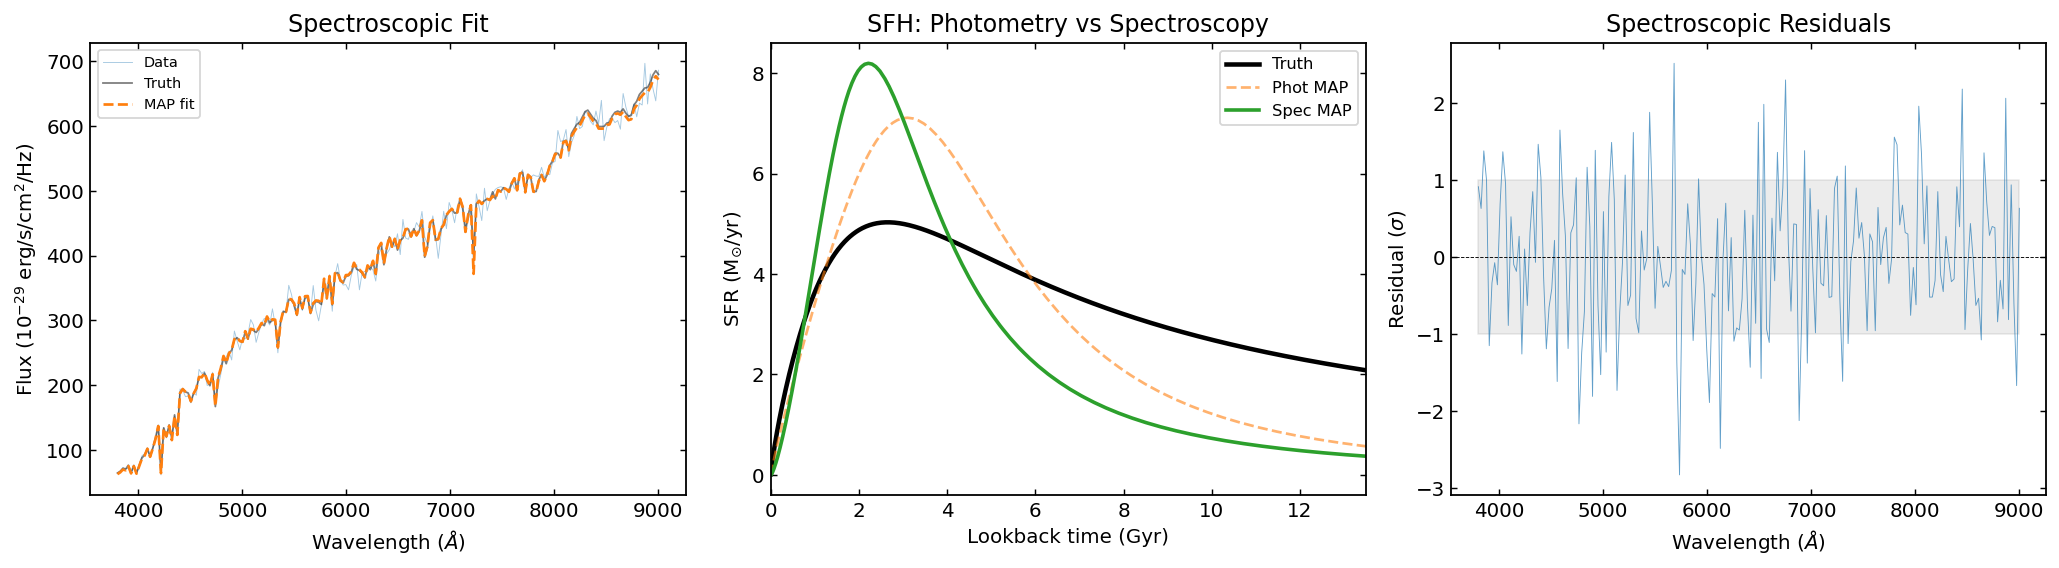

Parameter                  True   Phot MAP   Spec MAP
-------------------------------------------------------
dust_slope                 -0.7       -0.7       -0.7
dust_tau_bc                 0.8    0.00824       1.09
dust_tau_diff               0.3        0.3        0.3
met_logzsol                -0.2       -0.2       -0.2
redshift                    0.1        0.1        0.1
sfh_alpha                     1       2.63       2.25
sfh_beta                    0.8      0.904       1.35
sfh_peak_sfr                 10       12.6       15.9
sfh_tau_peak_gyr              3       4.19       2.56


In [12]:
# Compare spectroscopic fit to photometric fit
sfh_spec = model.predict_sfh(r_map_spec.params)
sed_spec_fit = model.predict_spectrum(r_map_spec.params, wave_spec)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Spectrum fit
ax = axes[0]
ax.plot(wave_spec, flux_spec_obs * 1e29, color="C0", alpha=0.4, lw=0.5, label="Data")
ax.plot(wave_spec, spec_true * 1e29, "k-", lw=1, alpha=0.5, label="Truth")
ax.plot(wave_spec, sed_spec_fit * 1e29, "C1--", lw=1.5, label="MAP fit")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Flux ($10^{-29}$ erg/s/cm$^2$/Hz)")
ax.set_title("Spectroscopic Fit")
ax.legend(fontsize=8)

# SFH comparison: photometry vs spectroscopy
ax = axes[1]
ax.plot(sfh_true["t_gyr"], sfh_true["sfr_mean"], "k-", lw=2.5, label="Truth")
ax.plot(sfh_fit["t_gyr"], sfh_fit["sfr_mean"], "C1--", lw=1.5, label="Phot MAP", alpha=0.6)
ax.plot(sfh_spec["t_gyr"], sfh_spec["sfr_mean"], "C2-", lw=2, label="Spec MAP")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("SFH: Photometry vs Spectroscopy")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=9)

# Residuals
ax = axes[2]
residual = (flux_spec_obs - sed_spec_fit) / noise_spec
ax.plot(wave_spec, residual, "C0", lw=0.5, alpha=0.7)
ax.axhline(0, color="k", ls="--", lw=0.5)
ax.fill_between(wave_spec, -1, 1, color="gray", alpha=0.15)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"Residual ($\sigma$)")
ax.set_title("Spectroscopic Residuals")

plt.tight_layout()
plt.show()

# Parameter comparison table
summary_spec = r_map_spec.summary()
summary_phot = result.summary()
print(f"{'Parameter':<22s} {'True':>8s} {'Phot MAP':>10s} {'Spec MAP':>10s}")
print("-" * 55)
for name in sorted(true_params.keys()):
    if name in summary_spec and name in summary_phot:
        print(f"{name:<22s} {true_params[name]:>8.3g} "
              f"{summary_phot[name]['value']:>10.3g} "
              f"{summary_spec[name]['value']:>10.3g}")

---
## Key Takeaways

1. **`ParamSpec` controls everything**: what's free, what's fixed, and the prior bounds
2. **Fixing parameters** reduces dimensionality and improves SFH recovery
3. **Higher SNR** constrains the fit better, but gains flatten past SNR ~ 20
4. **Batch fitting** via `mock_batch` + loop; full `vmap` parallelization for production
5. **`Fitter`** gives direct control for chaining MAP -> NUTS -> Ray Tracing
6. **Ray Tracing** (Behroozi 2025) provides posterior samples with less overhead than NUTS
7. **Derived quantities** (M*, SFR, sSFR) are computed from the fitted SFH, not as free parameters
8. **Spectroscopic fitting** uses `data_type="spectroscopy"` with `model._wave_obs` set, giving tighter constraints than photometry alone